## Disciplina VIS101: Fundamentos em Visão Computacional

Transformações da geometria da imagem, como alterar o tamanho, deslocar, rotacionar e espelhar, são operações que reaparecem o tempo todo em visão computacional, do aumento de dados ao alinhamento de imagens.

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.figsize': (5, 4), 'font.size': 12})
print('Setup pronto.')

Setup pronto.


In [2]:
img = cv2.imread('../images/cat.jpeg')
print('Dimensões originais:', img.shape)

Dimensões originais: (900, 1600, 3)


### Redimensionamento de imagens

A função `cv2.resize` altera o tamanho da imagem. Podemos passar um tamanho de destino em pixels ou um fator de escala.

Dimensões da imagem reduzida: (200, 356, 3)


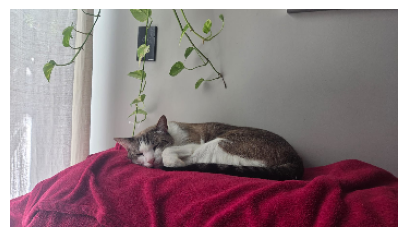

In [3]:
pequena = cv2.resize(img, (356, 200))
print('Dimensões da imagem reduzida:', pequena.shape)

plt.imshow(pequena[:, :, ::-1])
plt.axis("off")
plt.show()

In [4]:
metade = cv2.resize(img, None, fx=0.5, fy=0.5)
print('Dimensões da imagem reduzidas pela metade:', metade.shape)

Dimensões da imagem reduzidas pela metade: (450, 800, 3)


### Translação de Imagens (Deslocamento)

A célula de código abaixo realiza o deslocamento da imagem nos eixos X e Y. O OpenCV utiliza uma **Matriz de Transformação Afim**.

**1. A Matriz de Translação (`M`)**

Para mover a imagem, usamos uma matriz matemática de 2 linhas e 3 colunas:

$$
\begin{bmatrix}
\text{Escala X (1)} & \text{Inclinação X (0)} & \text{Deslocamento } t_x \\
\text{Inclinação Y (0)} & \text{Escala Y (1)} & \text{Deslocamento } t_y
\end{bmatrix}
$$

No nosso código, definimos `M = np.float32([[1, 0, 100], [0, 1, 50]])`:
* A 1ª linha `[1, 0, 100]`: mantém escala (1), não inclina (0), e **desloca 100 pixels para a direita**.
* A 2ª linha `[0, 1, 50]`: não inclina (0), mantém escala (1), e **desloca 50 pixels para baixo**.

**2. O passo a passo:**

* `h, w = img.shape[:2]`: Pega os índices 0 (Altura) e 1 (Largura), ignorando os canais de cor.
* `cv2.warpAffine(img, M, (w, h))`: Aplica o deslocamento. Recebe a imagem, a matriz `M` e o tamanho final. *(O OpenCV exige passar a largura `w` antes da altura `h`)*.

Dimensões da imagem deslocada: (900, 1600, 3)


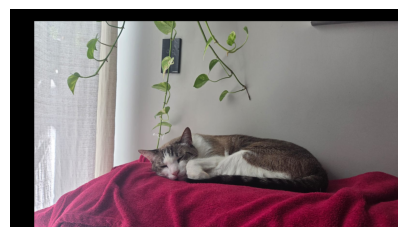

In [5]:
h, w = img.shape[:2] #obtendo as dimensões da imagem (altura e largura)
M = np.float32([[1, 0, 100], [0, 1, 50]]) # desloca 100 em x e 50 em y

deslocada = cv2.warpAffine(img, M, (w, h))
print('Dimensões da imagem deslocada:', deslocada.shape)

plt.imshow(deslocada[:, :, ::-1])
plt.axis('off')
plt.show()

### Rotação de imagens

Para rotacionar a imagem criamos uma matriz de rotação com o `cv2.getRotationMatrix2D`, informandoo centro, oângulo e a escala, e aplicamos també o `warpAffine`.

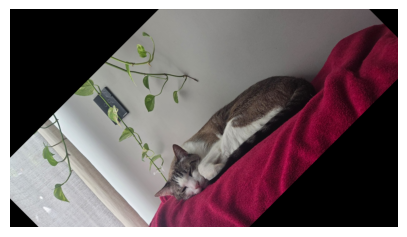

In [7]:
M = cv2.getRotationMatrix2D((w / 2, h / 2), 45, 1) # 45 graus em torno do centro da imagem (w / 2, h / 2))

rotacionada = cv2.warpAffine(img, M, (w, h)) # rotaciona a imagem

plt.imshow(rotacionada[:, :, ::-1])
plt.axis('off')
plt.show()

## Espelhamento

O espelhamento inverte a imagem, ara isso usamos o `cv2.flip`, o código 1 espelha na horizontal e o 0 na vertical.

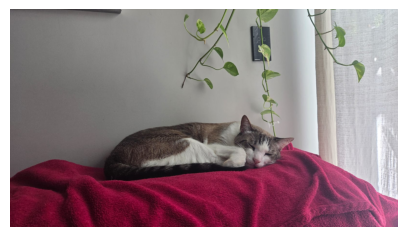

In [9]:
espelhada  = cv2.flip(img, 1) # espelha a imagem em relação ao eixo y

plt.imshow(espelhada[:, :, ::-1])
plt.axis('off')
plt.show()

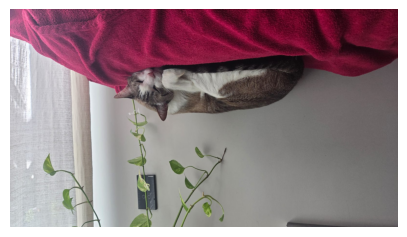

In [10]:
espelhada_x  = cv2.flip(img, 0) # espelha a imagem em relação ao eixo x

plt.imshow(espelhada_x[:, :, ::-1])
plt.axis('off')
plt.show()

### Síntese

Redimensionar usa `cv2.resize`. Transladar e rotacionar usam uma matriz de transformação aplicada por `cv2.warpAffine`. Espelhar usa `cv2.flip`. Todas operam sobre a mesma ideia: reposicionar os pixels segundo uma regra geométrica.